# EDA (Exploratory Data Analysis)

### **Date:** September 20, 2026

### **Summary:**

This dataset provides fully labeled motion capture and surface electromyography (sEMG) data acquired in a controlled laboratory environment. It is designed for biomechanical analysis, ergonomics, and machine learning models estimating joint torques, load weights, or movement kinetics. The goal of this notebook is to perform an initial exploratory data analysis (EDA) to understand the dataset's structure and contents.

**datos_unzipped/** contents (human-activity-recognition dataset, 14 subjects)

* `Data/` (10 GB, 679 CSVs): surface EMG (*electromiografías*) recordings, one folder per subject, one CSV per trial (~690 Hz). Columns: `Time`, `Raw_V_1..8` (raw voltage), `Norm_V_1..8` (rectified signal, %MVC) and `Norm_RMS_1..8` (250 ms RMS envelope, %MVC). File names encode subject, task (`Isokin`, `MMH_Bim`, `MMH_One`, `MVC_*`), side (L/R), load (kg) and condition (bpm, St static, or trial number).
* `Labels/` (679 CSVs): one file per EMG file (from previous folder). Regular trials list `Start_Frame`, `End_Frame`, `Label` segments using seven activity classes (N, LF, K, PT, LT, W, PF). MVC files (`*_range.csv`) only give the frame range used to compute the MVC reference value.
* `mvnx_files/` (56 GB, 517 files): Xsens MVN full-body motion capture (XML, 240 Hz, 23 segments), 36–37 files per subject, with no MVC recordings. Bimanual trials share one file across the L/R EMG trials.
* `Subjs_info.xlsx`: demographic and anthropometric table for the 14 subjects (12 M, 2 F, ages 25–38).
* `m_files/`: MATLAB preprocessing scripts (50 Hz notch, 20 Hz–Nyquist band-pass, 2-sample moving average, rectification, MVC normalisation, 250 ms RMS envelope) that produced the normalised columns.

**Contents:** 

1. Setup 
2. File inventory 
3. Participants 
4. sEMG recordings 
5. Activity labels 
6. sEMG signal quality 
7. Example trials 
8. sEMG vs. activity 
9. Motion capture (MVNX) 
10. Summary of findings
11. Glossary

*Sources:*
- *Data: https://zenodo.org/records/4633087*
- *Paper: G. Bassani, A. Filippeschi, C. A. Avizzano, "A Dataset of Human Motion and Muscular Activities in Manual Material Handling Tasks for Biomechanical and Ergonomic Analyses", IEEE Sensors Journal, vol. 21, no. 21, 2021. https://ieeexplore.ieee.org/document/9539228*

# 1. Setup

Dependencies: `numpy`, `pandas`, `matplotlib`, `openpyxl` (to read `Subjs_info.xlsx`).

The two heavy passes over the 10 GB of sEMG CSVs (sections 4 and 6) are cached in `notebooks/_cache/`. Set `REFRESH = True` to recompute them.

In [16]:
import re                        # parse file names and scan MVNX (XML) text
import time                      # time the slow file scans
from itertools import product    # cartesian products (expected trials, heatmap cell loops)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Definition or max number of columns and widths in posterior prints
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## To modify the matplotlib configuration in posterior plots
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

In [17]:
## Paths (the notebook lives in notebooks/, the unzipped data in datos_unzipped/)
ROOT = Path.cwd().resolve().parent / "datos_unzipped"
EMG_DIR, LABEL_DIR, MVNX_DIR = ROOT / "Data", ROOT / "Labels", ROOT / "mvnx_files"
SUBJ_XLSX = ROOT.parent / "datos" / "Subjs_info.xlsx"    # this file stays in datos/, it is not inside datos_unzipped/

## Create a _cache to save intermediate results
CACHE_DIR = Path.cwd() / "_cache"
CACHE_DIR.mkdir(exist_ok=True) # If the folder exists, do not create a new one
REFRESH = False    # True = ignore the cached scans in _cache/ and recompute them (slow)

# Fail early if a folder/file is missing (usually: the notebook was launched from the wrong folder)
for d in (EMG_DIR, LABEL_DIR, MVNX_DIR, SUBJ_XLSX):
    assert d.exists(), f"Not found: {d} (run the notebook from the notebooks/ folder)"

## sEMG columns
N_CH = 8
RAW = [f"Raw_V_{i}" for i in range(1, N_CH + 1)]         # raw voltage [V]
NORM_V = [f"Norm_V_{i}" for i in range(1, N_CH + 1)]     # rectified, %MVC
NORM_RMS = [f"Norm_RMS_{i}" for i in range(1, N_CH + 1)] # 250 ms RMS envelope, %MVC

## Activity labels (definitions from Bassani et al. as reused in the HAR literature on this dataset)
LABELS = {
    "N": "N-pose", 
    "LF": "Lift from floor", 
    "K": "Keep lifted", 
    "PT": "Place on table",
    "LT": "Lift from table", 
    "W": "Walk / carry",
    "PF": "Place on floor",
}
LABEL_ORDER = list(LABELS)    # class order used in every table and plot
# One fixed color per class, reused in all the plots
LABEL_COLORS = dict(zip(LABEL_ORDER, ["#9e9e9e", "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]))

# 2. File inventory

`datos_unzipped/` contains three modalities that share the same trial naming:

| Folder | Content | Format |
|---|---|---|
| `Data/Subj_XX/` | sEMG, 8 channels, one CSV per trial | CSV |
| `Labels/Subj_XX/` | activity segments (`*_EMG_labels.csv`) or MVC window (`*_EMG_range.csv`) | CSV |
| `mvnx_files/Subj_XX/` | Xsens full-body motion capture, one file per trial | MVNX (XML) |
| `Subjs_info.xlsx` | anthropometry of the 14 participants | XLSX |
| `m_files/` | MATLAB scripts used by the authors to filter and normalize the sEMG | `.m` |

The trial identity is encoded in the file name, so the first step is to parse it into a table.

In [18]:
# File-name patterns; the named groups (?P<...>) are read with groupdict() in parse_files.
# sEMG trial: Subj_03_Isokin_L_04kg_60bpm_EMG_data.csv    MVC: Subj_02_MVC_All_L_EMG_data.csv
# The optional (?:...)? blocks let one pattern match both (MVC files have no load/condition).
EMG_RE = re.compile(
    r"Subj_(?P<subject>\d+)_(?:(?P<mvc>MVC)_)?(?P<task>Isokin|MMH_Bim|MMH_One|All)_(?P<side>[LR])"
    r"(?:_(?P<load_kg>\d+)kg_(?P<condition>St|\d+bpm|Trial_\d))?_EMG_data\.csv"
)
# Motion capture: Subj_03_MMH_Bim_08kg_Trial_2.mvnx (bimanual trials have no side, hence it is optional)
MVNX_RE = re.compile(
    r"Subj_(?P<subject>\d+)_(?P<task>Isokin|MMH_Bim|MMH_One)(?:_(?P<side>[LR]))?"
    r"_(?P<load_kg>\d+)kg_(?P<condition>St|\d+bpm|Trial_\d)\.mvnx"
)


def parse_files(paths, regex):
    # One row per file; subject / task / side / load / condition are read from the file name
    rows = []
    for p in paths:
        m = regex.fullmatch(p.name)    # the whole name must match, otherwise fail loudly
        if m is None:
            raise ValueError(f"Unexpected file name: {p.name}")
        d = m.groupdict()
        rows.append(dict(
            file=p.name, path=p, subject=int(d["subject"]), task=d["task"], side=d["side"],
            is_mvc=d.get("mvc") is not None,    # only EMG_RE has an "mvc" group (hence .get)
            # side is None for bimanual MVNX files, load_kg is NaN for MVC files
            load_kg=float(d["load_kg"]) if d["load_kg"] else np.nan, condition=d["condition"],
        ))
    return pd.DataFrame(rows)


# Inventory of the sEMG files (sorted so the row order is reproducible)
emg = parse_files(sorted(EMG_DIR.glob("Subj_*/*.csv")), EMG_RE)
# key = trial name without the suffix; it links a sEMG file with its label file
emg["key"] = emg.file.str.replace("_EMG_data.csv", "", regex=False)
# Label file of each sEMG file: *_labels.csv for trials, *_range.csv (MVC window) for MVC files
emg["label_path"] = [
    LABEL_DIR / f"Subj_{s:02d}" / f"{k}_EMG_{'range' if mvc else 'labels'}.csv"
    for s, k, mvc in zip(emg.subject, emg.key, emg.is_mvc)
]
# Inventory of the motion-capture files
mocap = parse_files(sorted(MVNX_DIR.glob("Subj_*/*.mvnx")), MVNX_RE)

print(f"sEMG files: {len(emg)} ({(~emg.is_mvc).sum()} trials + {emg.is_mvc.sum()} MVC)")
# Every sEMG file should have its label file
print(f"label files with a matching sEMG file: {emg.label_path.map(Path.exists).sum()} / {len(emg)}")
print(f"MVNX files: {len(mocap)}")

sEMG files: 679 (643 trials + 36 MVC)
label files with a matching sEMG file: 679 / 679
MVNX files: 517


In [19]:
## Example: 
## In Data/ folder we have 17 sub-folders with sEMG records, one folder per subject. 
display(emg.head(5))

,file,path,subject,task,side,is_mvc,load_kg,condition,key,label_path
0,Subj_01_Isokin_L_02kg_40bpm_EMG_data.csv,/Users/yutsilflores/Documents/GitHub/human-act...,1,Isokin,L,False,2.0,40bpm,Subj_01_Isokin_L_02kg_40bpm,/Users/yutsilflores/Documents/GitHub/human-act...
1,Subj_01_Isokin_L_02kg_60bpm_EMG_data.csv,/Users/yutsilflores/Documents/GitHub/human-act...,1,Isokin,L,False,2.0,60bpm,Subj_01_Isokin_L_02kg_60bpm,/Users/yutsilflores/Documents/GitHub/human-act...
2,Subj_01_Isokin_L_02kg_80bpm_EMG_data.csv,/Users/yutsilflores/Documents/GitHub/human-act...,1,Isokin,L,False,2.0,80bpm,Subj_01_Isokin_L_02kg_80bpm,/Users/yutsilflores/Documents/GitHub/human-act...
3,Subj_01_Isokin_L_02kg_St_EMG_data.csv,/Users/yutsilflores/Documents/GitHub/human-act...,1,Isokin,L,False,2.0,St,Subj_01_Isokin_L_02kg_St,/Users/yutsilflores/Documents/GitHub/human-act...
4,Subj_01_Isokin_L_04kg_40bpm_EMG_data.csv,/Users/yutsilflores/Documents/GitHub/human-act...,1,Isokin,L,False,4.0,40bpm,Subj_01_Isokin_L_04kg_40bpm,/Users/yutsilflores/Documents/GitHub/human-act...


### Experimental design and completeness

Each subject performs 37 trials in the motion-capture system:

- **Isokinetic (`Isokin`)**: one arm (`L`/`R`), loads 2 and 4 kg, static (`St`) and 40/60/80 bpm → 16 trials.
- **MMH bimanual (`MMH_Bim`)**: loads 2, 8, 12 kg × 3 trials → 9 trials. The sEMG is recorded on both arms, so there is one `Bim_L` and one `Bim_R` sEMG file per trial, but a single MVNX file.
- **MMH one-handed (`MMH_One`)**: `L`/`R`, loads 2 and 4 kg × 3 trials → 12 trials.

From this design we can build the expected list of trials and check what is missing.

In [20]:
# The trials every subject should have according to the experimental design, to detect missing files
def expected_trials(with_side_for_bim):
    # with_side_for_bim: sEMG has a Bim_L and a Bim_R file per trial, MVNX has a single file (side = None)
    rows = []
    # Isokinetic: 2 sides x 2 loads x (static + 3 metronome rates)
    for side, load, cond in product("LR", (2, 4), ("St", "40bpm", "60bpm", "80bpm")):
        rows.append(("Isokin", side, load, cond))
    # MMH bimanual: (2 sides or none) x 3 loads x 3 trials
    for side, load, t in product("LR" if with_side_for_bim else [None], (2, 8, 12), (1, 2, 3)):
        rows.append(("MMH_Bim", side, load, f"Trial_{t}"))
    # MMH one-handed: 2 sides x 2 loads x 3 trials
    for side, load, t in product("LR", (2, 4), (1, 2, 3)):
        rows.append(("MMH_One", side, load, f"Trial_{t}"))
    exp = pd.DataFrame(rows, columns=["task", "side", "load_kg", "condition"])
    exp["load_kg"] = exp.load_kg.astype(float)    # same dtype as parse_files, needed for the merge
    # the same design for each of the 14 subjects
    return pd.concat([exp.assign(subject=s) for s in range(1, 15)], ignore_index=True)


# Left join expected -> found: rows that exist only on the left ("left_only") are the missing files
def find_missing(found, expected):
    keys = ["subject", "task", "side", "load_kg", "condition"]
    merged = expected.merge(found[keys], on=keys, how="left", indicator=True)
    return merged[merged._merge == "left_only"].drop(columns="_merge")


print("Missing sEMG trials:")
print(find_missing(emg[~emg.is_mvc], expected_trials(True)).to_string(index=False))
print("\nMissing MVNX trials:")
print(find_missing(mocap, expected_trials(False)).to_string(index=False))

Missing sEMG trials:
  task side  load_kg condition  subject
Isokin    L      2.0     80bpm       12

Missing MVNX trials:
  task side  load_kg condition  subject
Isokin    L      2.0     80bpm       12


In [21]:
## Files per subject and task (sEMG trials, MVC, MVNX)
summary = pd.concat({
    "sEMG trials": emg[~emg.is_mvc].groupby(["subject", "task"]).size().unstack(fill_value=0),
    "sEMG MVC": emg[emg.is_mvc].groupby("subject").size().rename("MVC").to_frame(),
    "MVNX": mocap.groupby("subject").size().rename("MVNX").to_frame(),
}, axis=1)
summary

sEMG trials                 sEMG MVC MVNX
             Isokin MMH_Bim MMH_One      MVC MVNX
subject                                          
1                16      18      12        6   37
2                16      18      12        2   37
3                16      18      12        2   37
4                16      18      12        2   37
5                16      18      12        2   37
6                16      18      12        2   37
7                16      18      12        2   37
8                16      18      12        2   37
9                16      18      12        2   37
10               16      18      12        2   37
11               16      18      12        6   37
12               15      18      12        2   36
13               16      18      12        2   37
14               16      18      12        2   37

MVC (maximum voluntary contraction) files are the reference used to normalize the sEMG to %MVC. Subjects 1 and 11 have one MVC recording per task (`Isokin`, `MMH_Bim`, `MMH_One`, per side); the others have a single `All` recording per side.

# 3. Participants

In [22]:
# One row per subject (ID 1-14) with demographics and body measurements
subj = pd.read_excel(SUBJ_XLSX).set_index("ID")

## Example of  Subjects information dataset: 
display(subj.head(5))

print(subj.Sex.value_counts().to_dict())
# mean, std, min, median and max of every numeric column
subj.describe().T[["mean", "std", "min", "50%", "max"]].round(1)

,Sex,Age,Body_mass,Body_height,Foot_length,Shoulder_height,Shoulder_width,Elbow_span,Wrist_span,Arm_span,Hip_height,Hip_width,Knee_height,Ankle_height,Extra_shoe_thickeness
ID,,,,,,,,,,,,,,,
1,M,38,70,181,29.5,151.0,44,93.7,142.8,182,106.0,34.0,52.0,10,1
2,M,37,79,184,30.0,156.0,39,95.0,141.0,183,103.0,37.0,59.0,13,3
3,F,35,58,166,26.0,140.0,38,83.0,122.0,161,97.0,28.0,52.0,14,8
4,M,28,78,187,32.0,152.0,41,96.0,146.0,186,100.0,34.0,52.0,14,3
5,M,25,72,180,30.0,154.0,45,89.0,144.0,180,105.0,33.0,54.0,13,1


{'M': 12, 'F': 2}


,mean,std,min,50%,max
Age,30.6,4.6,25.0,28.0,38.0
Body_mass,71.6,7.8,58.0,72.0,90.0
Body_height,178.6,5.4,166.0,179.0,187.0
Foot_length,29.3,1.8,25.0,29.8,32.0
Shoulder_height,148.7,5.0,140.0,148.5,156.0
Shoulder_width,41.6,3.9,32.0,42.0,46.0
Elbow_span,88.8,5.9,76.0,90.5,96.0
Wrist_span,133.8,13.2,103.0,140.5,148.0
Arm_span,176.6,8.6,161.0,177.5,188.0
Hip_height,101.3,3.8,96.0,100.9,108.0


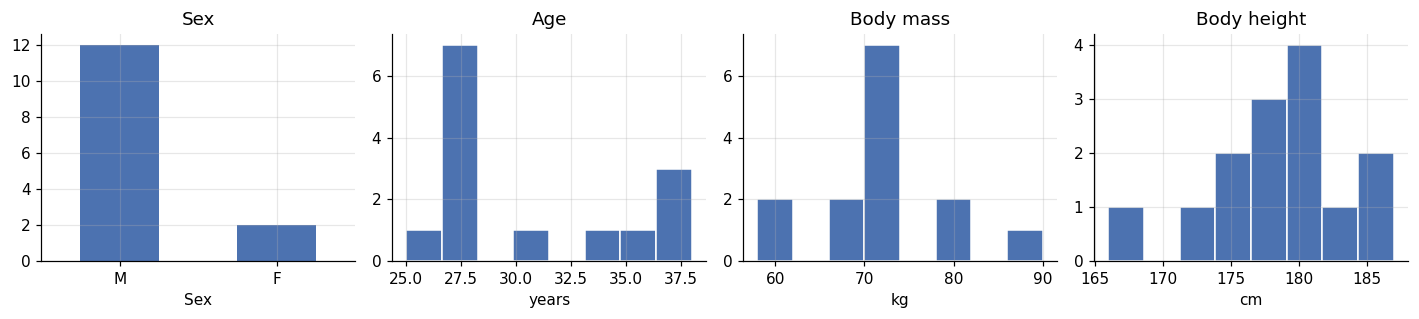

In [23]:
# First panel: subjects per sex; the other three: histograms of age, body mass and height
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
subj.Sex.value_counts().plot.bar(ax=axes[0], color="#4c72b0", rot=0, title="Sex")
for ax, col, unit in zip(axes[1:], ["Age", "Body_mass", "Body_height"], ["years", "kg", "cm"]):
    ax.hist(subj[col], bins=8, color="#4c72b0", edgecolor="white")
    ax.set(title=col.replace("_", " "), xlabel=unit)
fig.tight_layout()

The cohort is small (14 subjects, 12 M / 2 F, 25–38 years) and homogeneous, so **subject-independent generalization cannot be assessed with a random split of trials**: any evaluation should split by subject (e.g. leave-one-subject-out). Anthropometric columns (`Shoulder_height`, `Arm_span`, ...) are the Xsens calibration inputs and could also be used as covariates.

# 4. sEMG recordings

Every trial CSV has a `Time` column (Unix time in ms) and 8 channels in three versions: `Raw_V_k` (raw voltage), `Norm_V_k` and `Norm_RMS_k` (rectified and RMS-envelope, both in %MVC). The MVC recordings only have `Time` + `Raw_V_k` (17 columns instead of 25).

Parsing 10 GB of CSV just to get the sizes is slow, so the row count and the first/last timestamp are read without parsing the file. It still has to read every byte once: a few seconds if the files are in the OS cache, several minutes on a cold disk. The result is cached.

In [24]:
def scan_csv(path):
    """Row count and first/last timestamp without parsing the whole CSV."""
    n = 0
    with open(path, "rb") as fh:
        fh.readline()                # skip the header
        first = fh.readline()        # first data row -> first timestamp
        fh.seek(0)
        # count line breaks in 16 MB chunks: much faster than parsing the CSV
        while chunk := fh.read(1 << 24):
            n += chunk.count(b"\n")
        fh.seek(-4096, 2)    # jump to the last 4 KB of the file
        last = fh.read().strip().split(b"\n")[-1]    # last line -> last timestamp
    # n - 1: the line count includes the header
    return n - 1, float(first.split(b",")[0]), float(last.split(b",")[0])

# Scan every file (row count, first and last timestamp). Slow, so the result is cached.
SCAN_CSV = CACHE_DIR / "emg_scan.csv"
t0 = time.time()
if SCAN_CSV.exists() and not REFRESH:
    scan = pd.read_csv(SCAN_CSV)
else:
    scan = pd.DataFrame([scan_csv(p) for p in emg.path], columns=["n_rows", "t0_ms", "t1_ms"])
    scan.insert(0, "file", emg.file.to_numpy())
    scan.to_csv(SCAN_CSV, index=False)

# add n_rows, t0_ms and t1_ms to the inventory
emg = emg.merge(scan, on="file")
emg["duration_s"] = (emg.t1_ms - emg.t0_ms) / 1000 # Duration of records in seconds
emg["fs_hz"] = (emg.n_rows - 1) / emg.duration_s   # effective sampling rate (n_rows samples = n_rows - 1 intervals) - Frecuencia de muestreo
print(f"scanned in {time.time() - t0:.0f} s, {emg.n_rows.sum() / 1e6:.1f} M samples, {emg.duration_s.sum() / 3600:.1f} h recorded in total")
emg[["n_rows", "duration_s", "fs_hz"]].describe().round(1) # n_rows - number of rows in each csv in emg, duration and frequency

# n rows: Total de registros del archivo
# duration_s: Duración de la grabación
# fs_hz: Registros por segundo n_rows/duration_s

scanned in 0 s, 27.7 M samples, 13.2 h recorded in total


,n_rows,duration_s,fs_hz
count,679.0,679.0,679.0
mean,40854.6,69.9,585.3
std,15403.0,16.7,156.6
min,9750.0,9.7,366.7
25%,32250.0,60.9,498.2
50%,37800.0,72.4,529.1
75%,45875.0,82.0,581.7
max,103950.0,113.9,1005.6


The sampling rate is **not the same for all files**: it ranges from ~370 to ~1006 Hz. This matters because the label indices (section 5) are sample indices, so converting them to seconds requires the per-file rate. The following plot shows whether it depends on the subject.

The frequency differences (in Hz) are dependent upon subject-specific metrics, due to significant inter-subject variation.

subject,1,2,3,4,5,6,7,8,9,10,11,12,13,14
min,690.0,503.0,519.0,388.0,367.0,474.0,476.0,505.0,466.0,521.0,887.0,494.0,620.0,448.0
median,814.0,525.0,540.0,456.0,427.0,516.0,511.0,533.0,511.0,567.0,999.0,533.0,712.0,495.0
max,932.0,547.0,596.0,490.0,470.0,555.0,539.0,558.0,550.0,598.0,1006.0,586.0,891.0,542.0


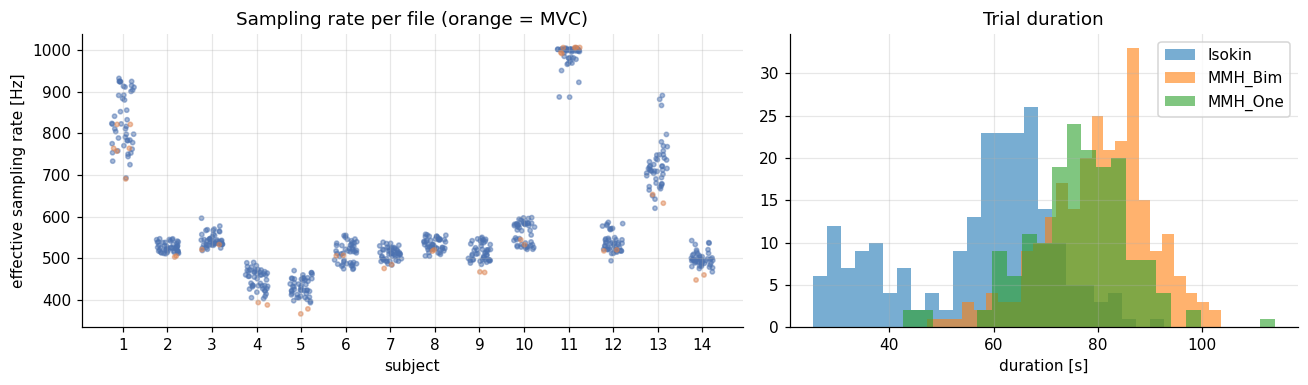

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.3, 1]})
# Left: sampling rate of every file by subject (x jittered with a fixed seed so points do not overlap)
rng = np.random.default_rng(0)
axes[0].scatter(emg.subject + rng.uniform(-0.25, 0.25, len(emg)), emg.fs_hz, s=8, alpha=0.5, c=np.where(emg.is_mvc, "#dd8452", "#4c72b0"))
axes[0].set(xlabel="subject", ylabel="effective sampling rate [Hz]", title="Sampling rate per file (orange = MVC)", xticks=range(1, 15))
# Right: histogram of the trial duration per task
for task, g in emg[~emg.is_mvc].groupby("task"):
    axes[1].hist(g.duration_s, bins=25, alpha=0.6, label=task)
axes[1].set(xlabel="duration [s]", title="Trial duration"); axes[1].legend()
fig.tight_layout()

# Min / median / max sampling rate of each subject
emg.groupby("subject").fs_hz.agg(["min", "median", "max"]).round(0).T

Within a file the sampling is regular (checked over all files in section 6), but the rate changes between subjects and even between sessions of the same subject (e.g. 690–932 Hz for subject 1). The authors' `Process.m` also estimates the rate per file from the number of samples and the duration, so the rate is not a fixed property of the recording setup. Any model that consumes windows of samples must **resample to a common rate** (or window by time, not by number of samples).

# 5. Activity labels


Each trial has a label file with one row per segment: `Start_Frame`, `End_Frame`, `Label`. The indices refer to **rows of the sEMG file** (the largest `End_Frame` is always below the number of sEMG samples). The seven classes are:

| Code | Activity | | Code | Activity |
|---|---|---|---|---|
| `N` | N-pose (neutral standing) | | `LT` | Lifting from the table |
| `LF` | Lifting from the floor | | `W` | Walking / carrying |
| `K` | Keeping the object lifted | | `PF` | Placing on the floor |
| `PT` | Placing on the table | | | |

(Definitions taken from the paper that uses this dataset for activity recognition: Sensors 25(21), 6705, 2025)

In [ ]:
# This chunk combines Label files into a single table, lab, with one labeled segment. 
# It then calculates duration and checks for label consistency

trials = emg[~emg.is_mvc]    # MVC files only have a window, not per-class labels(MVC no tiene etiquetas de actividad)
# All label files in one long table: one row per labeled segment, tagged with its file
lab = pd.concat([pd.read_csv(r.label_path).assign(file=r.file) for r in trials.itertuples()], ignore_index=True)
# Add the trial metadata plus the number of samples and sampling rate of the recording
lab = lab.merge(trials[["file", "subject", "task", "side", "load_kg", "condition", "n_rows", "fs_hz"]], on="file")
lab["seg"] = lab.groupby("file").cumcount()    # segment number within its file (0, 1, 2, ...)
lab["seg_samples"] = lab.End_Frame - lab.Start_Frame + 1    # length in samples (End_Frame is inclusive)
lab["seg_s"] = lab.seg_samples / lab.fs_hz    # length in seconds
# next Start_Frame - this End_Frame (< 0 means the segments overlap; NaN for the last segment of a file)
lab["gap_to_next"] = lab.groupby("file").Start_Frame.shift(-1) - lab.End_Frame

display(lab.head(5))
# Sanity checks: valid class names, no missing labels, no segment beyond the end of the recording
print(f"{len(lab)} segments in {lab.file.nunique()} label files")
print("Label values:", sorted(lab.Label.unique()), "| missing:", lab.Label.isna().sum())
print("Segments ending beyond the last sEMG sample:", int((lab.End_Frame >= lab.n_rows).sum()))

,Start_Frame,End_Frame,Label,file,subject,task,side,load_kg,condition,n_rows,fs_hz,seg,seg_samples,seg_s,gap_to_next
0,14402,16884,N,Subj_01_Isokin_L_02kg_40bpm_EMG_data.csv,1,Isokin,L,2.0,40bpm,55050,692.828148,0,2483,3.583861,3.0
1,16887,17898,LT,Subj_01_Isokin_L_02kg_40bpm_EMG_data.csv,1,Isokin,L,2.0,40bpm,55050,692.828148,1,1012,1.460680,3.0
2,17901,19367,PT,Subj_01_Isokin_L_02kg_40bpm_EMG_data.csv,1,Isokin,L,2.0,40bpm,55050,692.828148,2,1467,2.117408,3.0
3,19370,23441,N,Subj_01_Isokin_L_02kg_40bpm_EMG_data.csv,1,Isokin,L,2.0,40bpm,55050,692.828148,3,4072,5.877359,2.0
4,23443,24431,LT,Subj_01_Isokin_L_02kg_40bpm_EMG_data.csv,1,Isokin,L,2.0,40bpm,55050,692.828148,4,989,1.427482,2.0


10612 segments in 643 label files
Label values: ['K', 'LF', 'LT', 'N', 'PF', 'PT', 'W'] | missing: 0
Segments ending beyond the last sEMG sample: 0


We have 46 trails per subject, so, we have: 

| Tarea | Por sujeto  | Datos|
|---|---|---|
| Isokin | 16 | 223|
| MMH_Bim | 18 | 252 |
| MMH_One | 12 | 168 |

The code reads all 643 label files and stacks their rows into the lab table. Its final size is the sum of the rows across all 643 files:

* 643 label files
* 10,612 total rows
* Average of 16.5 segments per file (ranging from a minimum of 4 to a maximum of 19)

### Consistency of the annotations

Segments should be ordered and non-overlapping, with a tiny gap (a couple of samples) between consecutive segments.

In [27]:
# How far apart consecutive segments are (the mode is the usual gap)
print("Gap between consecutive segments [samples]:")
print(lab.gap_to_next.describe().round(1).to_string())
print("\nTypical gap (mode):", lab.gap_to_next.mode().iloc[0])

# Inconsistent segments: empty or inverted (end before start), or overlapping the next segment
bad = lab[(lab.seg_samples <= 0) | (lab.gap_to_next < 0)]
print(f"\nInconsistent segments (empty/inverted or overlapping the next one): {len(bad)} in {bad.file.nunique()} files")
# Show the whole segment table of every affected file
for f in bad.file.unique():
    print("\n", f)
    print(lab.loc[lab.file == f, ["seg", "Start_Frame", "End_Frame", "Label", "seg_samples"]].to_string(index=False))

Gap between consecutive segments [samples]:
count    9969.0
mean        1.1
std        62.5
min     -4832.0
25%         2.0
50%         2.0
75%         3.0
max      1894.0

Typical gap (mode): 2.0

Inconsistent segments (empty/inverted or overlapping the next one): 11 in 2 files

 Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv
 seg  Start_Frame  End_Frame Label  seg_samples
   0         6941       7940     N         1000
   1         6941       9083    LF         2143
   2         7942      10445     K         2504
   3         9085      11608    PT         2524
   4        10447      12953     N         2507
   5        11610      13822    LT         2213
   6        12955      18656     W         5702
   7        13824      16764    PF         2941
   8        18658      17905     N         -752
   9        16766      19169    LF         2404
  10        17907      20198    PT         2292
  11        19171      21166     N         1996

 Subj_05_Isokin_L_04kg_80bpm_EMG_data.csv
 seg  S

Two files have inconsistent annotations and should be reviewed or excluded before training: in the one-handed trial of subject 2 two label sequences overlap in time (start/end times are not monotonic), and in the isokinetic trial of subject 5 the last `N` segment is empty (`End_Frame < Start_Frame`).

In [41]:
BAD_LABEL_FILES = set(bad.file)    # files with inconsistent labels (left out of the analyses that use `valid`)
valid = lab[~lab.file.isin(BAD_LABEL_FILES)]    # label table without those files

## Segments per class and task
counts = lab.groupby(["task", "Label"]).size().unstack(fill_value=0)[LABEL_ORDER]
counts.loc["Total"] = counts.sum()    # add a total row
display(counts)

# Segment table of each excluded file
cols = ["seg", "Start_Frame", "End_Frame", "Label", "seg_samples", "gap_to_next"]
for f in sorted(BAD_LABEL_FILES):
    print(f)
    print(lab[lab["gap_to_next"] < 0].loc[lab.file == f, cols].to_string(index=False), "\n")

## Segments per class and task
counts = lab.groupby(["task", "Label"]).size().unstack(fill_value=0)[LABEL_ORDER]
counts.loc["Total"] = counts.sum()    # add a total row
counts


Label,N,LF,K,PT,LT,W,PF
task,,,,,,,
Isokin,1107,0,56,884,884,0,0
MMH_Bim,1434,706,252,706,484,484,484
MMH_One,989,492,168,492,330,330,330
Total,3530,1198,476,2082,1698,814,814


Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv
 seg  Start_Frame  End_Frame Label  seg_samples  gap_to_next
   0         6941       7940     N         1000       -999.0
   1         6941       9083    LF         2143      -1141.0
   2         7942      10445     K         2504      -1360.0
   3         9085      11608    PT         2524      -1161.0
   4        10447      12953     N         2507      -1343.0
   5        11610      13822    LT         2213       -867.0
   6        12955      18656     W         5702      -4832.0
   8        18658      17905     N         -752      -1139.0
   9        16766      19169    LF         2404      -1262.0
  10        17907      20198    PT         2292      -1027.0 

Subj_05_Isokin_L_04kg_80bpm_EMG_data.csv
Empty DataFrame
Columns: [seg, Start_Frame, End_Frame, Label, seg_samples, gap_to_next]
Index: [] 



Label,N,LF,K,PT,LT,W,PF
task,,,,,,,
Isokin,1107,0,56,884,884,0,0
MMH_Bim,1434,706,252,706,484,484,484
MMH_One,989,492,168,492,330,330,330
Total,3530,1198,476,2082,1698,814,814


The classes present depend on the task: **Isokinetic trials only contain `N`, `LT`, `PT` (and `K` in the static condition)**, while the MMH tasks contain all seven. `N` is by far the most frequent label.

The next figure shows how the recorded *time* is distributed among classes (class imbalance seen by a classifier) and how long each activity lasts.

Label,N,LF,K,PT,LT,W,PF
segments,3520.00,1196.00,475.00,2075.00,1692.00,813.00,813.00
hours,3.74,0.84,0.73,1.29,0.79,0.67,0.62
median_s,3.66,2.43,4.40,2.21,1.65,2.97,2.75
share_%,43.05,9.71,8.45,14.81,9.13,7.70,7.16


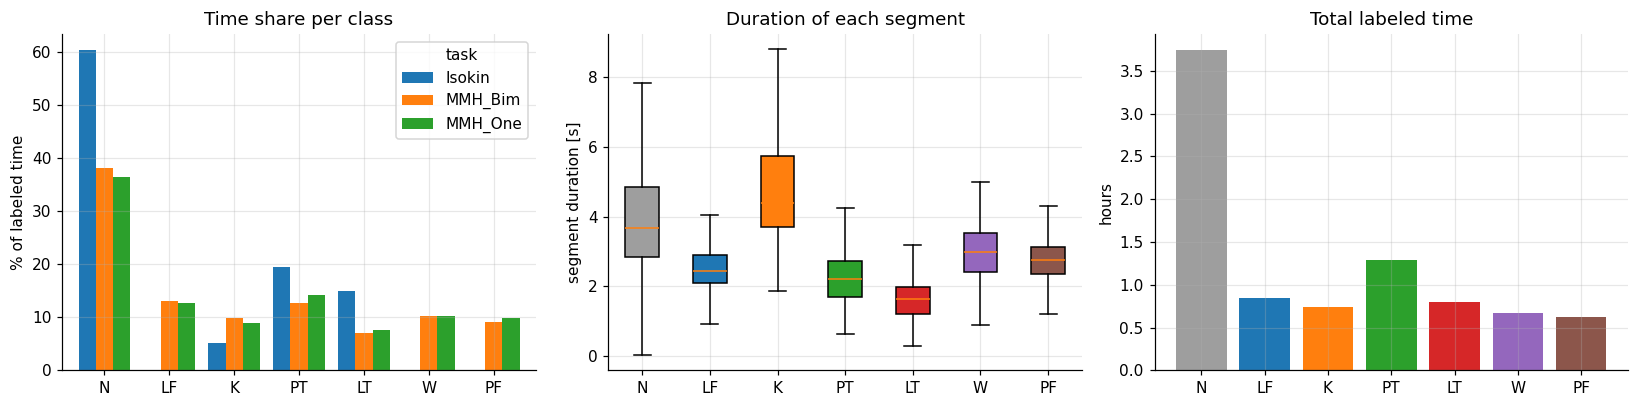

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# Left: share of the labeled time taken by each class within each task (every task adds up to 100 %)
time_share = valid.pivot_table(index="task", columns="Label", values="seg_s", aggfunc="sum", fill_value=0)[LABEL_ORDER]
(time_share.div(time_share.sum(axis=1), axis=0) * 100).T.plot.bar(ax=axes[0], rot=0, width=0.8)
axes[0].set(ylabel="% of labeled time", title="Time share per class", xlabel="")

# Middle: duration of the individual segments of each class (outliers hidden)
data = [valid.loc[valid.Label == l, "seg_s"] for l in LABEL_ORDER]
bp = axes[1].boxplot(data, tick_labels=LABEL_ORDER, patch_artist=True, showfliers=False)
# paint each box with its class color
for patch, l in zip(bp["boxes"], LABEL_ORDER):
    patch.set_facecolor(LABEL_COLORS[l])
axes[1].set(ylabel="segment duration [s]", title="Duration of each segment")

# Right: total labeled hours per class
axes[2].bar(LABEL_ORDER, valid.groupby("Label").seg_s.sum().reindex(LABEL_ORDER) / 3600, color=[LABEL_COLORS[l] for l in LABEL_ORDER])
axes[2].set(ylabel="hours", title="Total labeled time")
fig.tight_layout()

# Summary table per class: number of segments, hours, median duration and share of the labeled time
tot = valid.groupby("Label").agg(segments=("seg", "size"), hours=("seg_s", lambda s: s.sum() / 3600), median_s=("seg_s", "median"))
tot["share_%"] = tot.hours / tot.hours.sum() * 100
tot.reindex(LABEL_ORDER).round(2).T

### Structure of a trial

Label sequences follow a script. The table below lists the most frequent complete sequences.

In [30]:
# Label sequence of each trial written as a string, e.g. "N LF K PT N ..."
seqs = valid.groupby(["task", "file"]).Label.apply(" ".join).reset_index()
# Count how many trials share each sequence, then keep the 3 most common ones per task
top = seqs.groupby(["task", "Label"]).size().rename("trials").reset_index().sort_values(["task", "trials"], ascending=[True, False])
top.groupby("task").head(3).reset_index(drop=True)

,task,Label,trials
0,Isokin,N LT PT N LT PT N LT PT N LT PT N LT PT N,140
1,Isokin,N LT K PT N,56
2,Isokin,N LT PT N LT PT N LT PT N LT PT N LT PT N LT PT N,15
3,MMH_Bim,N LF K PT N LT W PF N LF PT N LT W PF N LF PT N,210
4,MMH_Bim,N LF K PT N LT W PF N,16
5,MMH_Bim,N LF K PT N LT W PF N LF PT N LT W PF N,14
6,MMH_One,N LF K PT N LT W PF N LF PT N LT W PF N LF PT N,158
7,MMH_One,N LF K PT N LT W PF N,3
8,MMH_One,N LF K PT N LT W PF N LF PT N LT W PF N,3


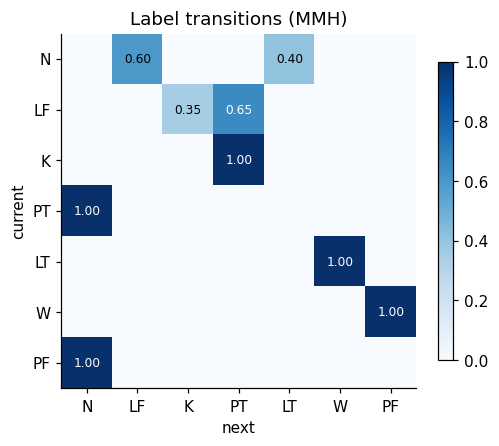

In [31]:
## Transition probabilities P(next label | current label), MMH trials only
mmh = valid[valid.task.str.startswith("MMH")].copy()
# label of the next segment in the same file (NaN for the last one)
mmh["next"] = mmh.groupby("file").Label.shift(-1)
# Count (current, next) pairs keeping all 7 x 7 classes even if a pair never occurs,
# then divide each row by its total so that it becomes P(next | current)
trans = pd.crosstab(mmh.Label, mmh["next"]).reindex(index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0)
trans = trans.div(trans.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(trans, cmap="Blues", vmin=0, vmax=1)
ax.set(xticks=range(7), yticks=range(7), xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, xlabel="next", ylabel="current", title="Label transitions (MMH)")
ax.grid(False)
# write the probability in each non-empty cell (white text on dark cells)
for i, j in product(range(7), range(7)):
    if trans.iloc[i, j] > 0:
        ax.text(j, i, f"{trans.iloc[i, j]:.2f}", ha="center", va="center", color="white" if trans.iloc[i, j] > 0.6 else "black", fontsize=8)
fig.colorbar(im, shrink=0.8);

The MMH trials follow a fixed script: `N → LF → (K) → PT → N → LT → W → PF → N → LF → PT → N → LT → W → PF → N → LF → PT → N`, i.e. three lifts from the floor and two from the table, with `K` only in the first lift. The order is so regular that a sequence model can exploit context, whereas a classifier that sees a single 1 s window will have to separate movements that look alike but happen at different heights (`LF` vs `LT`, `PT` vs `PF`).

### Labeled coverage of each recording

,labeled_frac,lead_s,tail_s
count,641.00,641.00,641.00
mean,0.67,16.84,5.45
std,0.13,5.86,5.00
min,0.27,0.00,0.06
25%,0.62,13.75,2.67
50%,0.69,16.59,4.66
75%,0.75,20.26,6.83
max,0.99,38.75,50.15


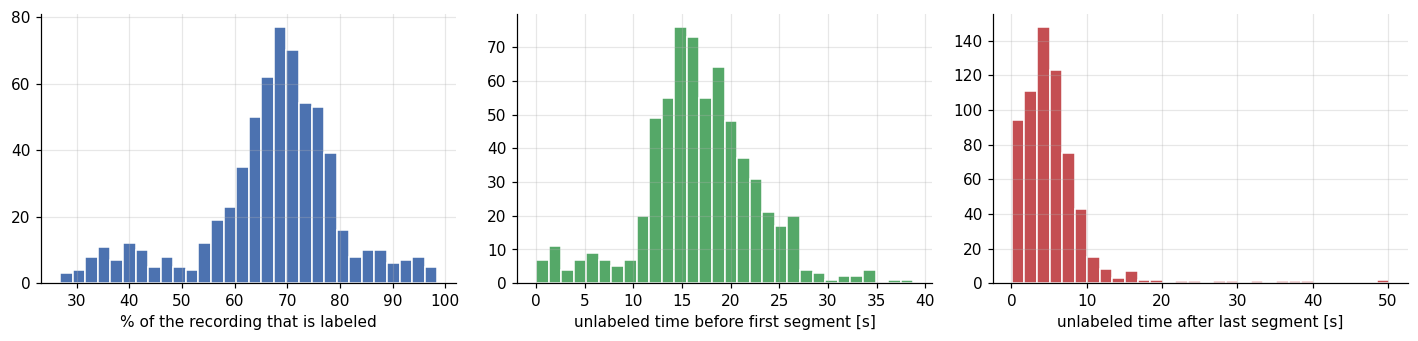

In [ ]:
# Labeling coverage per file: first / last labeled sample, number of labeled samples, recording size
cov = valid.groupby("file").agg(first=("Start_Frame", "min"), last=("End_Frame", "max"), labeled=("seg_samples", "sum"), n_rows=("n_rows", "first"), fs=("fs_hz", "first"))
cov["labeled_frac"] = cov.labeled / cov.n_rows    # fraction of the recording that is labeled
cov["lead_s"] = cov["first"] / cov.fs    # unlabeled seconds at the start
cov["tail_s"] = (cov.n_rows - cov["last"]) / cov.fs    # unlabeled seconds at the end

# Histograms of: labeled fraction, unlabeled time before the first segment, unlabeled time after the last
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].hist(cov.labeled_frac * 100, bins=30, color="#4c72b0", edgecolor="white"); axes[0].set(xlabel="% of the recording that is labeled")
axes[1].hist(cov.lead_s, bins=30, color="#55a868", edgecolor="white"); axes[1].set(xlabel="unlabeled time before first segment [s]")
axes[2].hist(cov.tail_s, bins=30, color="#AA3F43", edgecolor="white"); axes[2].set(xlabel="unlabeled time after last segment [s]")
fig.tight_layout()
cov[["labeled_frac", "lead_s", "tail_s"]].describe().round(2)

On average only ~two thirds of each recording is labeled: the sEMG starts a median of ~17 s before the first segment and runs ~5 s after the last one. Those samples have **no label** and must be dropped (or assigned to `N`, if that is justified) when building windows.

### MVC windows

Each `*_EMG_range.csv` marks the window of the MVC recording used to compute the reference amplitude (`Process.m` averages the RMS envelope inside it).

In [33]:
mvc = emg[emg.is_mvc].copy()    # the MVC recordings
# Each *_range.csv has one row (Start_Frame, End_Frame): the window used to compute the MVC reference
rng_df = pd.concat([pd.read_csv(p) for p in mvc.label_path], ignore_index=True)
# Window length in seconds (.to_numpy() aligns by position: rows are in the same order as `mvc`)
mvc["win_s"] = (rng_df.End_Frame - rng_df.Start_Frame + 1).to_numpy() / mvc.fs_hz.to_numpy()
print(mvc.win_s.describe().round(2).to_string())

count    36.00
mean      3.46
std       1.01
min       1.99
25%       2.44
50%       3.84
75%       4.10
max       5.46


# 6. sEMG signal quality

A single pass over all CSVs computes, per file: timestamp regularity, missing values, amplitude statistics for the 8 raw channels and (for trials) percentiles of the normalized signal; and, per labeled segment, the mean `Norm_RMS` of each channel (used in section 8). The result is cached.

In [42]:
# Per-file signal statistics for the quality checks. It reads every CSV once (slow), so the results are cached:
# FILE_CSV = one row per file, SEG_CSV = mean Norm_RMS of each labeled segment.
FILE_CSV, SEG_CSV = CACHE_DIR / "emg_file_stats.csv", CACHE_DIR / "emg_segment_stats.csv"
CH = range(1, N_CH + 1)    # channel numbers 1..8


def scan_emg(row):
    # MVC files have Raw and Rect (rectified) columns but no normalised ones: read only Raw for them
    cols = ["Time"] + RAW + ([] if row.is_mvc else NORM_V + NORM_RMS)
    d = pd.read_csv(row.path, usecols=cols, dtype=np.float64)
    t = d["Time"].to_numpy()
    dt = np.diff(t)    # sampling period between consecutive samples [ms]
    raw = d[RAW].to_numpy()    # (n_samples, 8)
    # File-level checks: missing values, sampling period (median / min / max), time gaps (period > 1.5x the
    # median) and timestamps that do not increase
    stats = dict(
        file=row.file, n_nan=int(d.isna().to_numpy().sum()),
        dt_med_ms=np.median(dt), dt_min_ms=dt.min(), dt_max_ms=dt.max(),
        n_gaps=int((dt > 1.5 * np.median(dt)).sum()), n_nonmono=int((dt <= 0).sum()),
    )
    # Per channel: mean, standard deviation and largest absolute value of the raw signal [V]
    for c, m, s, a in zip(CH, raw.mean(0), raw.std(0), np.abs(raw).max(0)):
        stats.update({f"raw_mean_{c}": m, f"raw_std_{c}": s, f"raw_absmax_{c}": a})
    segs = []
    if not row.is_mvc:
        # Per channel: 99th percentile of Norm_RMS and maximum of Norm_V (checks the %MVC scale)
        rms, nv = d[NORM_RMS].to_numpy(), d[NORM_V].to_numpy()
        for c, p99, mx in zip(CH, np.percentile(rms, 99, axis=0), nv.max(0)):
            stats.update({f"rms_p99_{c}": p99, f"normv_max_{c}": mx})
        # Mean Norm_RMS of every labeled segment, per channel (used in section 8)
        lab_df = pd.read_csv(row.label_path)
        for s0, s1, name in lab_df.itertuples(index=False):
            # skip inverted segments and segments that end beyond the recording
            if s1 < s0 or s1 >= len(d):
                continue
            # End_Frame is inclusive, hence s1 + 1
            segs.append(dict(file=row.file, Start_Frame=s0, End_Frame=s1, Label=name,
                             **{f"rms_{c}": v for c, v in zip(CH, rms[s0:s1 + 1].mean(0))}))
    return stats, segs


# Reuse the cached statistics if they exist; otherwise scan all the files (progress every 100 files)
if FILE_CSV.exists() and SEG_CSV.exists() and not REFRESH:
    file_stats, seg_stats = pd.read_csv(FILE_CSV), pd.read_csv(SEG_CSV)
else:
    t0, fs_rows, sg_rows = time.time(), [], []
    for i, row in enumerate(emg.itertuples(), 1):
        st, sg = scan_emg(row)
        fs_rows.append(st); sg_rows += sg
        if i % 100 == 0:
            print(f"{i}/{len(emg)} files, {time.time() - t0:.0f} s")
    file_stats, seg_stats = pd.DataFrame(fs_rows), pd.DataFrame(sg_rows)
    file_stats.to_csv(FILE_CSV, index=False); seg_stats.to_csv(SEG_CSV, index=False)
    print(f"done in {time.time() - t0:.0f} s")

# Add the file metadata (subject, task, side, load, ...) to the statistics
file_stats = emg[["file", "subject", "task", "side", "load_kg", "condition", "is_mvc", "fs_hz"]].merge(file_stats, on="file")
print(file_stats.shape, seg_stats.shape)

(679, 54) (10610, 12)


### Missing values and timestamps

In [43]:
# Timestamp checks over all files: missing values, order, gaps and period jitter
print("Missing values (all files, all columns read):", int(file_stats.n_nan.sum()))
print("Non-monotonic timestamps:", int(file_stats.n_nonmono.sum()))
print("Time gaps > 1.5x the sampling period:", int(file_stats.n_gaps.sum()))
# relative spread of the sampling period inside each file
jit = (file_stats.dt_max_ms - file_stats.dt_min_ms) / file_stats.dt_med_ms
print(f"Max period variation within a file (max-min)/median: {jit.max():.3%}")

Missing values (all files, all columns read): 0
Non-monotonic timestamps: 0
Time gaps > 1.5x the sampling period: 0
Max period variation within a file (max-min)/median: 1.011%


No missing values, and the timestamps are strictly increasing with a constant period inside each file (the ≤ 1 % variation is the rounding of the timestamps to 0.01 ms). So a single per-file sampling rate is enough to describe the time axis.

### Amplitude and outliers

In a typical file the raw channels have a standard deviation of a few tenths to a few mV and a peak |raw| of ~15 mV (median), with 90 % of the files below ~34 mV. The table lists the files with the largest absolute peak across channels.

In [20]:
# Names of the per-channel columns created in scan_emg: largest |raw| value and raw std
AMAX, ASTD = [f"raw_absmax_{c}" for c in CH], [f"raw_std_{c}" for c in CH]
# Amplitude per file in mV: largest |raw| of any channel, typical (median) channel std,
# and std of the noisiest channel
file_stats["absmax_mV"] = file_stats[AMAX].max(axis=1) * 1e3
file_stats["std_med_mV"] = file_stats[ASTD].median(axis=1) * 1e3
file_stats["std_max_mV"] = file_stats[ASTD].max(axis=1) * 1e3

print(file_stats.absmax_mV.describe(percentiles=[.5, .9, .99]).round(1).to_string())
# The 8 files with the largest peaks
file_stats.sort_values("absmax_mV", ascending=False)[["file", "absmax_mV", "std_med_mV", "std_max_mV"]].head(8).round(1)

count     679.0
mean       26.9
std       119.3
min         3.6
50%        15.1
90%        34.0
99%       104.1
max      1951.7


,file,absmax_mV,std_med_mV,std_max_mV
322,Subj_07_MMH_Bim_R_08kg_Trial_3_EMG_data.csv,1951.7,2.5,739.8
324,Subj_07_MMH_Bim_R_12kg_Trial_2_EMG_data.csv,1849.5,4.4,194.3
323,Subj_07_MMH_Bim_R_12kg_Trial_1_EMG_data.csv,1581.7,2.7,487.7
300,Subj_07_Isokin_R_02kg_40bpm_EMG_data.csv,150.7,7.8,19.8
303,Subj_07_Isokin_R_02kg_St_EMG_data.csv,122.2,5.7,23.3
294,Subj_07_Isokin_L_02kg_80bpm_EMG_data.csv,115.1,2.2,8.0
301,Subj_07_Isokin_R_02kg_60bpm_EMG_data.csv,113.0,4.1,13.1
293,Subj_07_Isokin_L_02kg_60bpm_EMG_data.csv,101.6,2.2,8.3


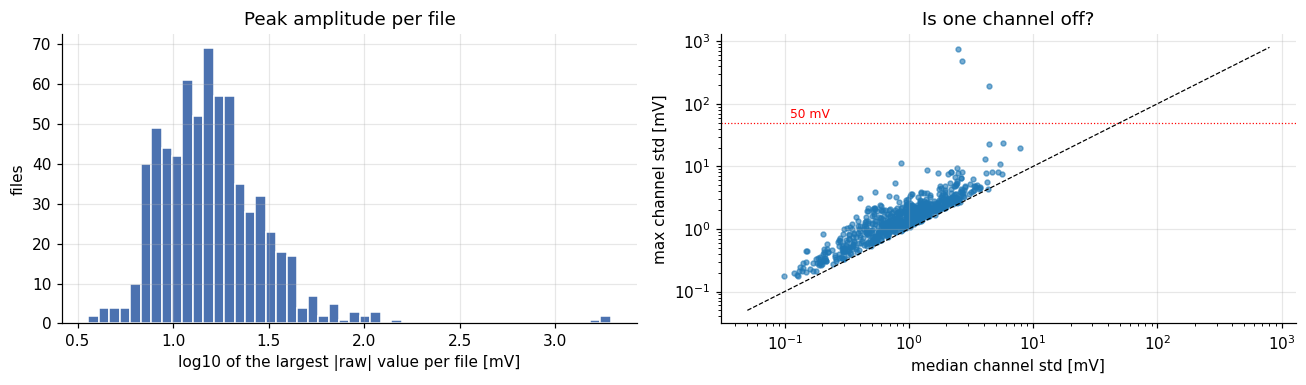

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
# Left: peak amplitude per file on a log scale
axes[0].hist(np.log10(file_stats.absmax_mV), bins=50, color="#4c72b0", edgecolor="white")
axes[0].set(xlabel="log10 of the largest |raw| value per file [mV]", ylabel="files", title="Peak amplitude per file")
# Right: noisiest channel vs typical channel of each file; a point far above the diagonal = one channel is off
axes[1].scatter(file_stats.std_med_mV, file_stats.std_max_mV, s=10, alpha=0.6)
axes[1].set(xscale="log", yscale="log", xlabel="median channel std [mV]", ylabel="max channel std [mV]", title="Is one channel off?")
axes[1].plot([0.05, 800], [0.05, 800], "k--", lw=0.8)    # diagonal: all channels alike
# outlier threshold (50 mV), applied in the next cell
axes[1].axhline(50, color="r", lw=0.8, ls=":"); axes[1].text(0.11, 60, "50 mV", color="r", fontsize=8)
fig.tight_layout()

There is a clear break: three files have a channel with a standard deviation above 100 mV, whereas in all the other files no channel exceeds ~25 mV. The rule below flags a file when any channel has a standard deviation above 50 mV.

In [22]:
## Outlier rule: a channel with std > 50 mV (typical values are ~1 mV)
STD_LIMIT_MV = 50
outliers = file_stats[file_stats.std_max_mV > STD_LIMIT_MV]    # at least one channel above the limit
BAD_EMG_FILES = set(outliers.file)    # left out of the signal analyses below
print(f"{len(outliers)} file(s) with a channel std > {STD_LIMIT_MV} mV:")
# std of every channel in the flagged files, to see which channels are off
for r in outliers.itertuples():
    stds = " ".join(f"{getattr(r, f'raw_std_{c}') * 1e3:7.1f}" for c in CH)
    print(f"  {r.file}\n    std per channel [mV]: {stds}")

## The other files with |raw| > 100 mV are noisy but not broken (channel std <= 25 mV)
noisy = file_stats[(file_stats.absmax_mV > 100) & ~file_stats.file.isin(BAD_EMG_FILES)]
print(f"\n{len(noisy)} noisy files (|raw| > 100 mV, kept): subject(s) {sorted(int(s) for s in noisy.subject.unique())}")

3 file(s) with a channel std > 50 mV:
  Subj_07_MMH_Bim_R_08kg_Trial_3_EMG_data.csv
    std per channel [mV]:     0.9     1.4     1.1     1.4     3.5     4.0   363.3   739.8
  Subj_07_MMH_Bim_R_12kg_Trial_1_EMG_data.csv
    std per channel [mV]:     1.3     0.9     0.6     1.1     4.1     6.0   487.7   252.0
  Subj_07_MMH_Bim_R_12kg_Trial_2_EMG_data.csv
    std per channel [mV]:     3.7     6.3     3.1     5.1     2.9     1.9   194.3   125.5

5 noisy files (|raw| > 100 mV, kept): subject(s) [7]


The three flagged files (all subject 7, right arm) have channels 7 and 8 with amplitudes of hundreds of mV up to ~2 V, i.e. 2–3 orders of magnitude above the rest. That indicates a loose electrode/cable artifact or saturation, not muscle activity. It also produces absurd normalized values (`Norm_V` up to ~3·10⁵ %MVC in the first of them), so these files must be excluded or those channels masked; they are excluded from the rest of the analysis. Five other files of the same subject have peaks above 100 mV but a normal standard deviation: they are noisy and are kept, but subject 7 is the least clean recording session.

*There are other five files, noisy but valid:*

These are five Isokin trials from the same subject (L_02kg_60bpm, L_02kg_80bpm, R_02kg_40bpm, R_02kg_60bpm, R_02kg_St). They exhibit high peaks between 100 and 150 mV; however, their maximum standard deviation ranges from 8 to 23 mV, indicating that the signal stays within a reasonable range most of the time. These peaks appear to be isolated artifacts rather than a continuous electrode failure. For this reason, they are retained, although the text notes that Subject 7 represents the least clean session.

### **Amplitude per subject and channel**

Median raw standard deviation over the trials of each subject (flagged files excluded):

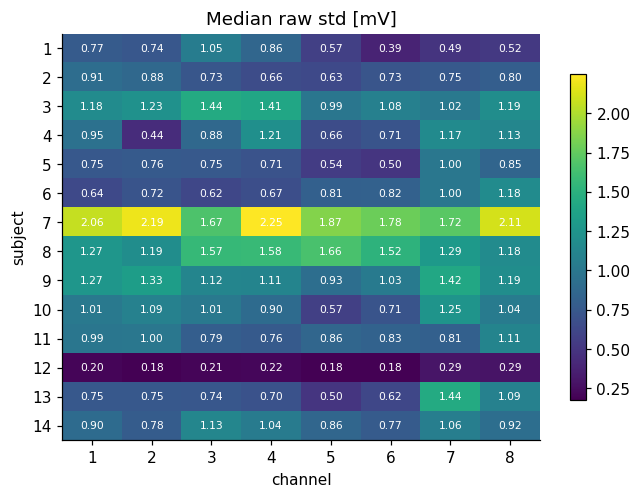

In [23]:
good = file_stats[~file_stats.file.isin(BAD_EMG_FILES)]    # files without the broken ones
amp = good.groupby("subject")[ASTD].median() * 1e3    # median raw std [mV] per subject and channel
amp.columns = list(CH)    # channel numbers 1..8

# Heatmap subjects x channels, with the value written in each cell
fig, ax = plt.subplots(figsize=(7, 4.8))
im = ax.imshow(amp, cmap="viridis", aspect="auto")
ax.set(xticks=range(N_CH), xticklabels=list(CH), yticks=range(14), yticklabels=amp.index, xlabel="channel", ylabel="subject", title="Median raw std [mV]")
ax.grid(False)
for i, j in product(range(14), range(N_CH)):
    ax.text(j, i, f"{amp.iloc[i, j]:.2f}", ha="center", va="center", color="white", fontsize=7)
fig.colorbar(im, shrink=0.8);

The raw amplitude differs by about an order of magnitude **between subjects** (~0.2 mV for subject 12 vs. ~2 mV for subject 7) and is broadly similar across channels within a subject. This is a subject/setup effect (skin impedance, gain, electrode placement), and it is partly inflated by the slow baseline drift of the raw signal (section 7), which is included in the standard deviation. It is the reason the authors normalize by each subject's MVC: raw voltage should not be fed to a model without per-subject normalization.

### Normalized signal (%MVC)

`Norm_RMS` is the RMS envelope in % of the MVC of the same subject. A value above 100 % means the task elicited more activity than the reference "maximum" contraction, which only happens if the MVC was underestimated (its window is just 2–5 s, see section 5).

In [24]:
# Trials only (MVC files have no Norm_RMS): one p99 value per file and channel
p99 = good[~good.is_mvc][[f"rms_p99_{c}" for c in CH]]
print("99th percentile of Norm_RMS per file and channel [%MVC]:")
print(p99.stack().describe(percentiles=[.5, .9]).round(1).to_string())
print(f"\nFiles where at least one channel exceeds 100 %MVC at p99: {(p99.max(axis=1) > 100).sum()} / {len(p99)}")
nv = good[~good.is_mvc][[f"normv_max_{c}" for c in CH]].stack()
print(f"Norm_V max: median {nv.median():.0f} %, p99 {nv.quantile(.99):.0f} %, max {nv.max():.0f} % (rectified, unsmoothed -> spiky)")

99th percentile of Norm_RMS per file and channel [%MVC]:
count    5120.0
mean       95.2
std        74.7
min         6.1
50%        78.6
90%       170.2
max      1581.8

Files where at least one channel exceeds 100 %MVC at p99: 434 / 640
Norm_V max: median 394 %, p99 4208 %, max 13498 % (rectified, unsmoothed -> spiky)


Exceeding 100 %MVC is the rule rather than the exception (most files), so `Norm_RMS` is **not bounded to 0–100** and the %MVC values should be read as a per-subject scale, not as an absolute effort. `Norm_V` (rectified, unsmoothed) reaches thousands of %MVC and is much spikier than the RMS envelope.

# 7. Example trials

Raw sEMG (channel 1) and the `Norm_RMS` envelope of the 8 channels, with the annotated segments shaded.

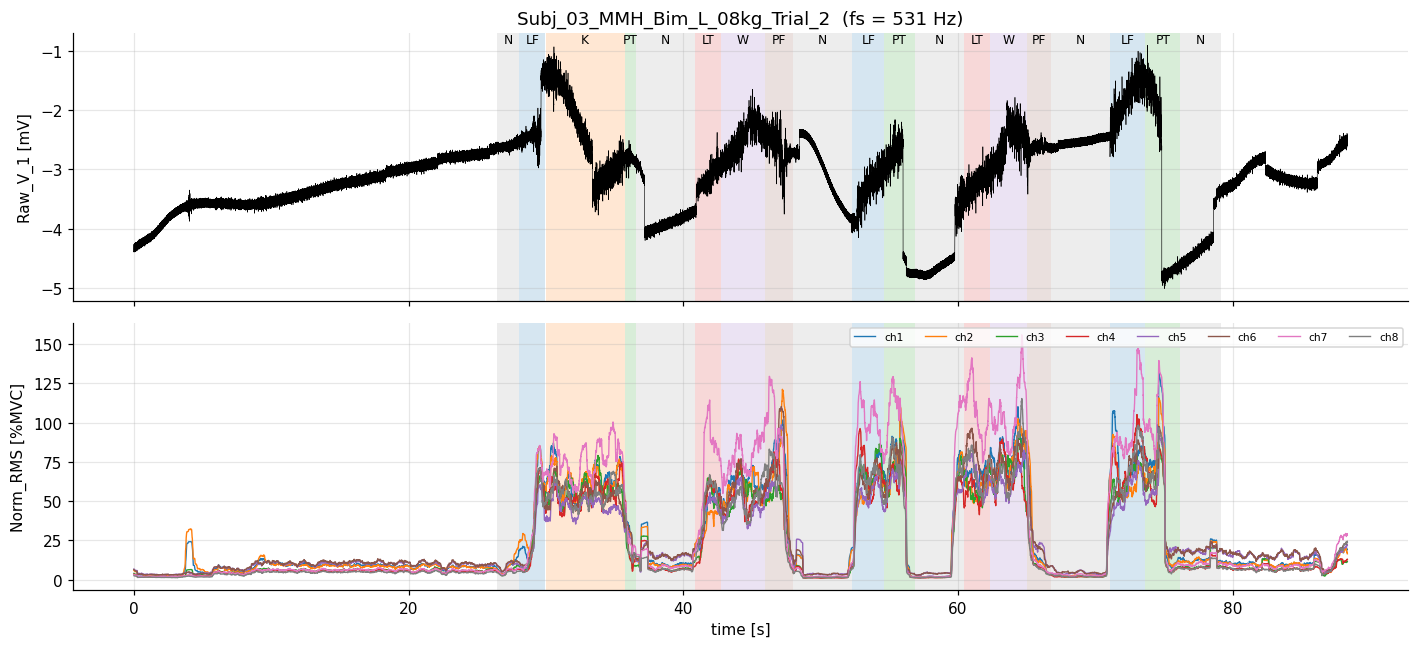

In [25]:
emg_by_key = emg.set_index("key")    # look files up by trial name


def plot_trial(key):
    # One trial: raw channel 1 on top, Norm_RMS of the 8 channels below, labeled segments shaded
    r = emg_by_key.loc[key]
    d, labs = pd.read_csv(r.path), pd.read_csv(r.label_path)
    t = (d.Time.to_numpy() - d.Time.iloc[0]) / 1000    # time since the start of the recording [s]
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    # top: raw channel 1 in mV
    axes[0].plot(t, d.Raw_V_1 * 1e3, lw=0.4, color="k")
    axes[0].set(ylabel="Raw_V_1 [mV]", title=f"{key}  (fs = {r.fs_hz:.0f} Hz)")
    # bottom: one line per channel
    for c in NORM_RMS:
        axes[1].plot(t, d[c], lw=0.9, label=c.replace("Norm_RMS_", "ch"))
    axes[1].set(ylabel="Norm_RMS [%MVC]", xlabel="time [s]")
    axes[1].legend(ncol=8, fontsize=7, loc="upper right")
    # shade each labeled segment; Start/End_Frame are sample indices, so t[frame] is the time
    for s0, s1, name in labs.itertuples(index=False):
        if s1 < s0:    # skip inverted segments
            continue
        # min(...) keeps the index inside the recording when a label ends beyond the last sample
        for ax in axes:
            ax.axvspan(t[s0], t[min(s1, len(t) - 1)], color=LABEL_COLORS[name], alpha=0.18, lw=0)
        # class name at the top of the segment
        axes[0].text((t[s0] + t[min(s1, len(t) - 1)]) / 2, axes[0].get_ylim()[1], name, ha="center", va="top", fontsize=8)
    fig.tight_layout()
    return d    # the data is returned so it can be reused (see the correlation plot)


d_bim = plot_trial("Subj_03_MMH_Bim_L_08kg_Trial_2")    # bimanual example: subject 3, left, 8 kg

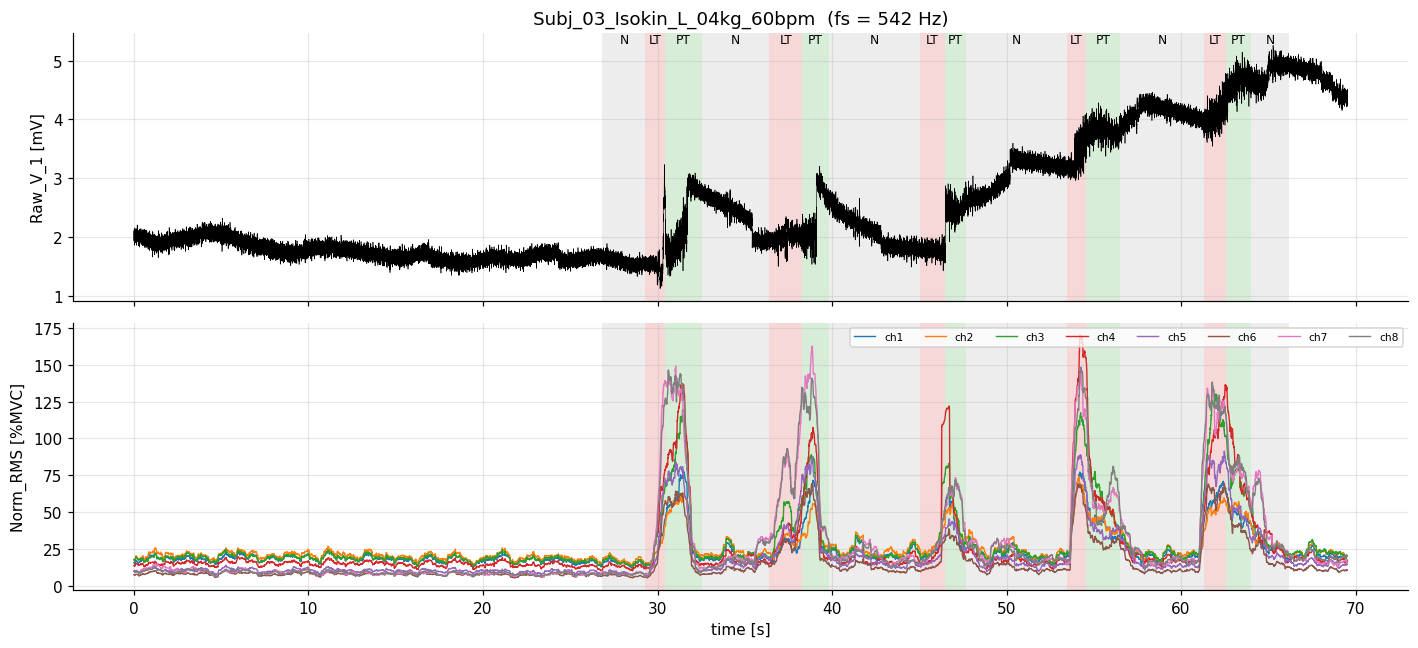

In [26]:
d_iso = plot_trial("Subj_03_Isokin_L_04kg_60bpm")    # isokinetic example: subject 3, left, 4 kg, 60 bpm

In the bimanual trial the envelope jumps from ~5–10 %MVC at rest to 50–100 % as soon as the object is lifted (`LF`, `LT`) and stays high while it is kept or carried, then drops during `N`. The first ~26 s of the recording is unlabeled. In the isokinetic trial each repetition (`LT` + `PT`) appears as a burst.

The raw signal (top) shows the other issue mentioned above: a baseline offset of several mV and slow drift, with the muscle activity riding on top as a change in the width of the trace. This is what the high-pass filter in `Process.m` removes before computing the envelope.

Correlation between channels, in the same bimanual trial:

Raw: min off-diagonal correlation = 0.67


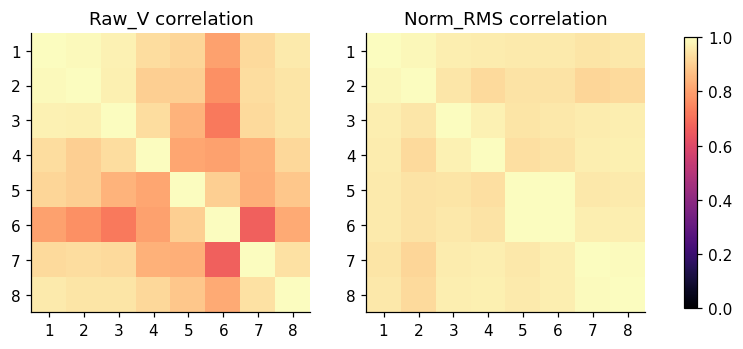

In [27]:
# Correlation between the 8 channels of the bimanual example: raw signal (left) and Norm_RMS (right)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, cols, title in zip(axes, (RAW, NORM_RMS), ("Raw_V", "Norm_RMS")):
    c = d_bim[cols].corr().to_numpy()
    im = ax.imshow(c, vmin=0, vmax=1, cmap="magma"); ax.grid(False)
    ax.set(title=f"{title} correlation", xticks=range(8), yticks=range(8), xticklabels=range(1, 9), yticklabels=range(1, 9))
fig.colorbar(im, ax=axes, shrink=0.8)
# Weakest correlation between two different channels (the diagonal is excluded)
print(f"Raw: min off-diagonal correlation = {np.min(d_bim[RAW].corr().to_numpy()[~np.eye(8, dtype=bool)]):.2f}")

The raw channels are **strongly correlated with each other** (off-diagonal correlation ≥ 0.67 here), so they do not behave as independent muscle signals: the shared slow drift dominates the raw correlation. The authors' pipeline (`Process.m`) applies a 50 Hz notch and a band-pass Butterworth filter (lower cut-off 20 Hz) before rectifying and computing the envelope. Working from `Norm_RMS` is safer than from `Raw_V`.

The mapping between channels 1–8 and muscles is **not documented** in the files. The Zenodo description lists four arm muscles (triceps, extensor digitorum, biceps, brachioradialis) while each file has 8 channels, and it does not say which channel is which. That has to be confirmed with the paper before interpreting individual channels.

# 8. sEMG vs. activity

Is the sEMG informative about the class? Using the per-segment mean `Norm_RMS` (excluding the flagged sEMG files and the inconsistent label files):

10527 segments used


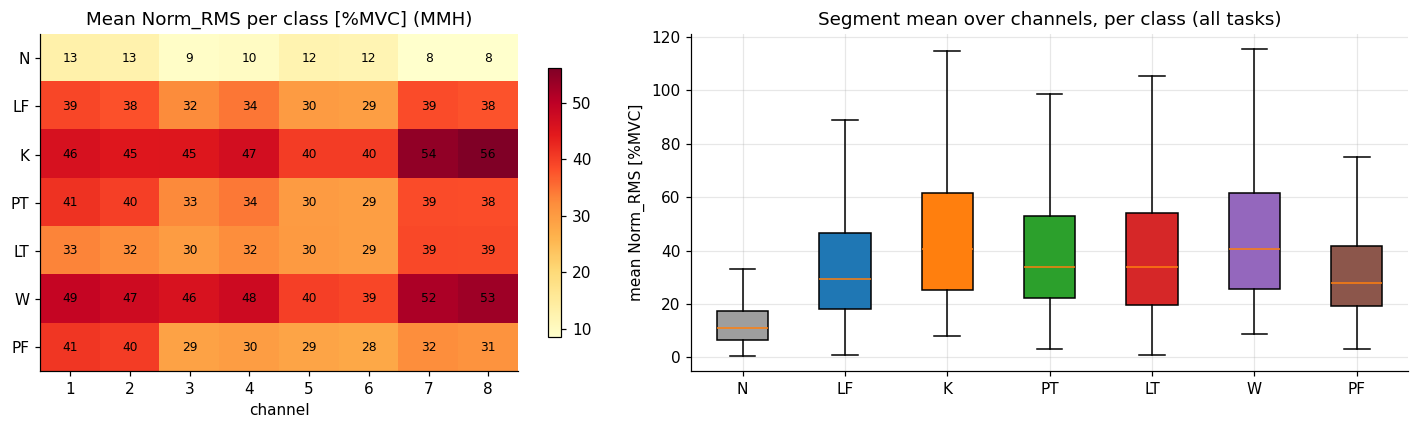

In [28]:
RMS_COLS = [f"rms_{c}" for c in CH]    # per-channel mean Norm_RMS of each segment (from scan_emg)
# Attach the trial metadata to each segment and drop the files flagged as broken (signal) or inconsistent (labels)
seg = seg_stats.merge(emg[["file", "subject", "task", "side", "load_kg", "condition"]], on="file")
seg = seg[~seg.file.isin(BAD_EMG_FILES | BAD_LABEL_FILES)].copy()
seg["rms_mean"] = seg[RMS_COLS].mean(axis=1)    # mean over the 8 channels
print(f"{len(seg)} segments used")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1, 1.2]})
# Left: mean Norm_RMS per class and channel (MMH trials)
heat = seg[seg.task.str.startswith("MMH")].groupby("Label")[RMS_COLS].mean().reindex(LABEL_ORDER)
im = axes[0].imshow(heat, cmap="YlOrRd", aspect="auto")
axes[0].set(xticks=range(N_CH), xticklabels=list(CH), yticks=range(7), yticklabels=LABEL_ORDER, xlabel="channel", title="Mean Norm_RMS per class [%MVC] (MMH)")
axes[0].grid(False)
# write the value in each cell
for i, j in product(range(7), range(N_CH)):
    axes[0].text(j, i, f"{heat.iloc[i, j]:.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes[0], shrink=0.8)

# Right: distribution of the segment means (averaged over channels) per class, all tasks
data = [seg.loc[seg.Label == l, "rms_mean"] for l in LABEL_ORDER]
bp = axes[1].boxplot(data, tick_labels=LABEL_ORDER, patch_artist=True, showfliers=False)
for patch, l in zip(bp["boxes"], LABEL_ORDER):
    patch.set_facecolor(LABEL_COLORS[l])
axes[1].set(ylabel="mean Norm_RMS [%MVC]", title="Segment mean over channels, per class (all tasks)")
fig.tight_layout()

The sEMG separates **rest from activity** very well: `N` is at ~8–13 %MVC in every channel, while all the other classes are roughly 3–6 times higher. Among the active classes (`K` and `W` the highest, ~40–55 %MVC; the lifts and placements ~30–40 %) the distributions overlap heavily, so sEMG alone is not enough to tell them apart and would need to be combined with the motion data.

Effect of the load (bimanual trials, mean over channels):

Label,N,LF,K,PT,LT,W,PF
load_kg,,,,,,,
2.0,9,20,22,23,19,22,21
8.0,10,37,53,39,32,51,34
12.0,12,50,75,47,45,73,43


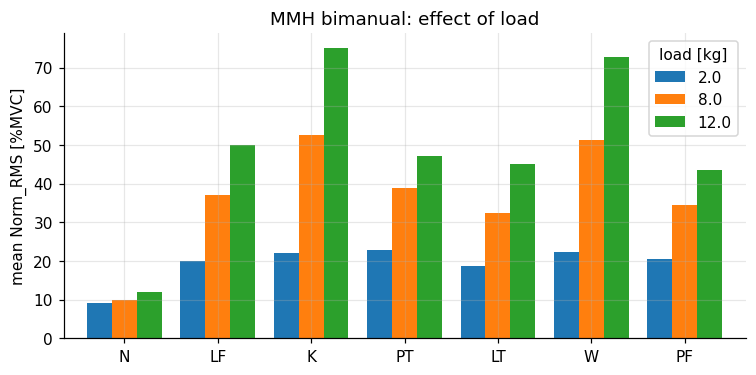

In [29]:
# Mean Norm_RMS per class (rows) and load (columns), bimanual MMH only
bim = seg[seg.task == "MMH_Bim"].groupby(["Label", "load_kg"]).rms_mean.mean().unstack()
# keep the class order, only the classes that occur
bim = bim.reindex([l for l in LABEL_ORDER if l in bim.index])
ax = bim.plot.bar(rot=0, figsize=(8, 3.6), width=0.8)
ax.set(ylabel="mean Norm_RMS [%MVC]", xlabel="", title="MMH bimanual: effect of load"); ax.legend(title="load [kg]")
# the same numbers as a rounded table (loads as rows)
bim.round(0).astype(int).T

The amplitude grows monotonically with the load in every active class (for `K` and `W` it roughly triples between 2 and 12 kg), while at rest (`N`) it barely changes. sEMG is therefore informative for **load estimation**, one of the intended uses of the dataset, and the load effect is as large as the differences between the active classes.

# 9. Motion capture (MVNX)

Motion is recorded with an Xsens MVN suit and exported as MVNX (XML, 240 Hz). The 517 files add up to ~57 GB, so the whole set cannot be parsed casually. Header information (frame rate, number of frames, timestamp of the first and last frame) is read from the first and last bytes of each file.

In [30]:
# MVNX files are ~100 MB of XML: instead of parsing them, read only their start and their end
def scan_mvnx(path):
    with open(path, "rb") as fh:
        head = fh.read(600_000).decode("utf8", "ignore")    # start of the file: frame rate, first frame
        fh.seek(-40_000, 2)    # end of the file: last frame
        tail = fh.read().decode("utf8", "ignore")
    # frame rate [Hz], timestamp [ms] of the first frame, and index + timestamp of the last frame.
    # Only type="normal" frames count: they are the recording (the file also has calibration frames).
    rate = int(re.search(r'frameRate="(\d+)"', head).group(1))
    ms0 = int(re.search(r'index="0" tc="[^"]*" ms="(\d+)" type="normal"', head).group(1))
    last = re.findall(r'index="(\d+)" tc="[^"]*" ms="(\d+)" type="normal"', tail)[-1]
    # (frame rate, number of frames = last index + 1, first timestamp, last timestamp)
    return rate, int(last[0]) + 1, ms0, int(last[1])


# Scan all the MVNX files: frame rate, number of frames and first / last timestamp
mocap[["frame_rate", "n_frames", "ms0", "ms1"]] = [scan_mvnx(p) for p in mocap.path]
mocap["duration_s"] = mocap.n_frames / mocap.frame_rate    # seconds = frames / frame rate
mocap["size_mb"] = [p.stat().st_size / 1e6 for p in mocap.path]
print("frame rates:", mocap.frame_rate.unique(), "| total size: %.0f GB" % (mocap.size_mb.sum() / 1e3))
mocap[["n_frames", "duration_s", "size_mb"]].describe().round(1)

frame rates: [240] | total size: 57 GB


,n_frames,duration_s,size_mb
count,517.0,517.0,517.0
mean,13775.3,57.4,109.7
std,3983.6,16.6,31.2
min,3085.0,12.9,24.8
25%,12166.0,50.7,97.6
50%,14091.0,58.7,112.3
75%,16039.0,66.8,127.1
max,29222.0,121.8,226.8


### Structure of one file

Each MVNX contains the skeleton definition (23 segments, 17 IMU sensors, 22 joints) and, for every frame, positions, orientations, velocities, accelerations, angular velocities, joint angles, center of mass, foot contacts and raw sensor data. The first three frames are calibration poses (`identity`, `tpose`, `tpose-isb`); the rest are `normal`.

In [31]:
example = MVNX_DIR / "Subj_03" / "Subj_03_MMH_Bim_08kg_Trial_2.mvnx"    # file used to inspect the structure


def read_mvnx_joints(path):
    """Joint names and (n_frames, n_joints, 3) joint angles [deg] of the 'normal' frames."""
    names, angles, started = [], [], False
    with open(path) as fh:
        for line in fh:
            if "<jointAngle>" in line:
                started = True    # first frame reached: joint names are only defined before it
                # one line per frame: the 3 angle components [deg] of every joint, separated by spaces
                angles.append(np.array(line.split(">")[1].split("<")[0].split(), dtype=float))
            elif "<joint label=" in line and not started:    # joint names come from the header only
                names.append(re.search(r'label="([^"]+)"', line).group(1))
    # shape (frames, joints, 3): 3 angle components per joint
    return names, np.array(angles).reshape(len(angles), -1, 3)


joint_names, angles = read_mvnx_joints(example)
print(f"{angles.shape[0]} frames x {angles.shape[1]} joints x 3 angles")
print("Joints:", ", ".join(joint_names))

15679 frames x 22 joints x 3 angles
Joints: jL5S1, jL4L3, jL1T12, jT9T8, jT1C7, jC1Head, jRightT4Shoulder, jRightShoulder, jRightElbow, jRightWrist, jLeftT4Shoulder, jLeftShoulder, jLeftElbow, jLeftWrist, jRightHip, jRightKnee, jRightAnkle, jRightBallFoot, jLeftHip, jLeftKnee, jLeftAnkle, jLeftBallFoot


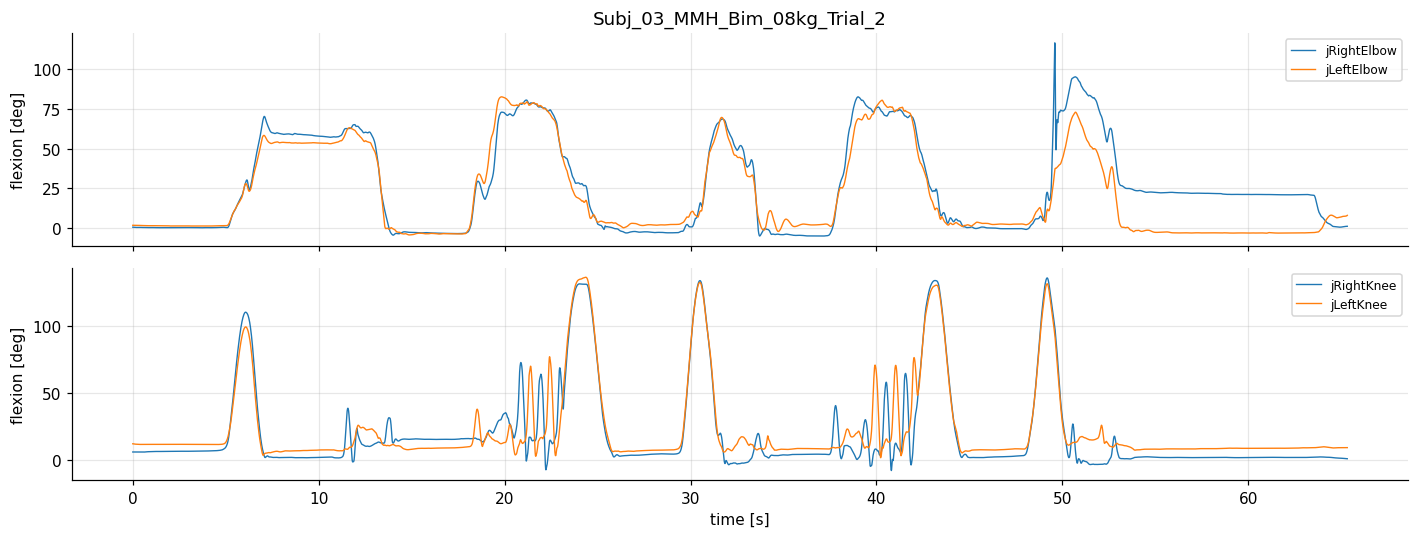

In [32]:
## Flexion/extension is the third angle component (z): it has the largest range for hips, knees and elbows
idx = {n: i for i, n in enumerate(joint_names)}
tt = np.arange(len(angles)) / 240    # time axis [s]: the MVNX frame rate is 240 Hz
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
# top: elbow flexion; bottom: knee flexion
for name in ("jRightElbow", "jLeftElbow"):
    axes[0].plot(tt, angles[:, idx[name], 2], lw=0.9, label=name)
for name in ("jRightKnee", "jLeftKnee"):
    axes[1].plot(tt, angles[:, idx[name], 2], lw=0.9, label=name)
axes[0].set(ylabel="flexion [deg]", title=example.stem); axes[1].set(ylabel="flexion [deg]", xlabel="time [s]")
for ax in axes:
    ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

### Synchronization between sEMG and motion capture

Labels are indexed on the sEMG samples, while motion is stored on its own time base. Both files carry Unix timestamps in ms, so they can be compared directly (for bimanual trials the single MVNX file is compared with both the `L` and `R` sEMG files).

643 sEMG-MVNX pairs
       clock_offset_s  duration_diff_s
count           643.0            643.0
mean           3596.8             12.0
std               5.3              8.1
min            3578.3            -35.7
25%            3594.3             10.2
50%            3596.5             12.7
75%            3597.6             16.1
max            3633.0             34.4


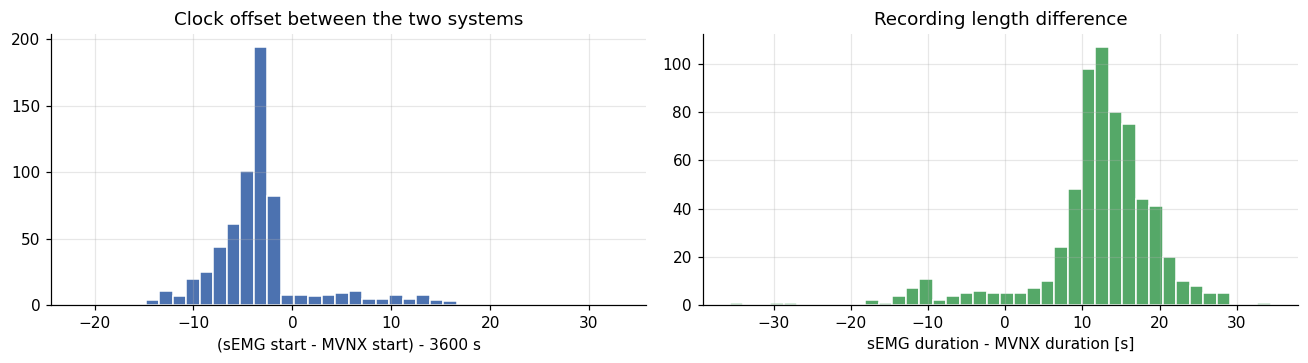

In [33]:
keys = ["subject", "task", "load_kg", "condition"]    # columns that identify the same trial in both systems
# Pair each MVNX file with the sEMG trials of the same subject / task / load / condition
pairs = mocap.merge(trials, on=keys, suffixes=("_mv", "_emg"))
# Bimanual MVNX files have no side (kept, paired with both arms); otherwise the side must match
pairs = pairs[pairs.side_mv.isna() | (pairs.side_mv == pairs.side_emg)].copy()
pairs["clock_offset_s"] = (pairs.t0_ms - pairs.ms0) / 1000       # sEMG start - MVNX start
pairs["duration_diff_s"] = pairs.duration_s_emg - pairs.duration_s_mv    # sEMG - MVNX

print(f"{len(pairs)} sEMG-MVNX pairs")
print(pairs[["clock_offset_s", "duration_diff_s"]].describe().round(1).to_string())

# Left: clock offset minus 1 h (the raw offset is ~3600 s, see the text below); right: recording length difference
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(pairs.clock_offset_s - 3600, bins=40, color="#4c72b0", edgecolor="white")
axes[0].set(xlabel="(sEMG start - MVNX start) - 3600 s", title="Clock offset between the two systems")
axes[1].hist(pairs.duration_diff_s, bins=40, color="#55a868", edgecolor="white")
axes[1].set(xlabel="sEMG duration - MVNX duration [s]", title="Recording length difference")
fig.tight_layout()

The sEMG clock is ahead of the motion-capture clock by about one hour (median 3596.5 s, most likely a time-zone setting on one of the acquisition computers), and the residual around 3600 s is a few seconds that **varies from trial to trial** (from about -22 s to +33 s). The sEMG recordings are also ~12 s longer than the motion capture on average. So the two streams cannot be aligned by timestamps alone: an alignment step per trial (e.g. matching an event visible in both, such as the first lift) is needed before fusing sEMG and motion, and before transferring the sEMG-based labels to the motion data. This notebook does not attempt that alignment.

# 10. Summary of findings

### What the dataset contains

- **14 subjects** (12 M / 2 F, 25–38 years), 37 trials each: 16 isokinetic, 9 bimanual MMH, 12 one-handed MMH. Subject 12 is the only incomplete one (`Isokin_L_02kg_80bpm` is missing in both modalities).
- **sEMG**: 643 trial CSVs + 36 MVC CSVs, 8 channels, 27.7 M samples (13.2 h). Bimanual trials have one file per arm.
- **Motion capture**: 517 MVNX files (~57 GB), Xsens at 240 Hz, 23 segments / 17 IMUs / 22 joints.
- **Labels**: 10,612 segments in 7 classes, ~8.7 h labeled. `N` is 43 % of the labeled time; the isokinetic trials only contain `N`, `LT`, `PT` (and `K` in the static condition).

### Issues to handle before modeling

| Issue | Evidence | Suggested handling |
|---|---|---|
| Sampling rate differs per file (367–1006 Hz) | section 4 | Compute the rate per file and resample, or window by time |
| Labels cover only ~2/3 of each recording | section 5 | Drop unlabeled samples (or justify mapping them to `N`) |
| 2 label files are inconsistent (overlapping / empty segments) | section 5: `Subj_02_MMH_One_R_02kg_Trial_2`, `Subj_05_Isokin_L_04kg_80bpm` | Fix or exclude |
| 3 sEMG files with broken channels 7–8 (up to ~2 V) | section 6: subject 7, `MMH_Bim_R` 08 kg trial 3 and 12 kg trials 1–2 | Exclude or mask the channels; 5 more subject-7 files are noisy |
| `Norm_RMS` is not bounded to 100 %MVC (434 of 640 trial files exceed it at p99) | section 6 | Treat %MVC as a per-subject scale |
| Raw signal has offset, drift and strongly correlated channels | sections 6–7 | Use `Norm_RMS`, or filter the raw signal as in `Process.m` |
| Channel → muscle mapping is not documented | section 7 | Confirm with the paper |
| sEMG and MVNX are not synchronized by timestamp (~1 h offset ± seconds, sEMG ~12 s longer) | section 9 | Per-trial alignment before fusing modalities |

### What the data suggests

- **Rest vs. activity** is easy for the sEMG (`N` ≈ 8–13 %MVC vs. 30–55 % for the active classes), but the active classes overlap heavily: distinguishing `LF`/`LT`/`PT`/`PF` will need the motion data and/or temporal context (the trial script is fixed: `N → LF → (K) → PT → N → LT → W → PF → ...`).
- **The load is visible in the sEMG**: in every active class the amplitude grows monotonically with the load (about 3× from 2 to 12 kg for `K` and `W`).
- **Small cohort**: with 14 subjects, evaluate by subject (leave-one-subject-out), not by random trial split, and keep the amplitude differences between subjects (0.2–2 mV raw) in mind.
- **Class imbalance**: `N` is 43 % of the time, the rest are 7–15 % each; the `K` class only appears once per MMH trial.

# 11. Glosary: 

* `Xsens MVN`: Es el sistema de captación de movimiento (motion capture) que se usó dentro de la captura de datos del dataset. Es el origen de los archivos `.mvnx` que se manejan dentro de este Notebook. Como funciona es que el sujeto se pone sensores inerciales (IMU) repartidos por el cuerpo y cada IMU combina un aceletrómetro, un giroscopio y un magnetómetro para capturar el movimiento. 

* `sEMG` *(Surface Electromyography)* : Es un estudio médito y tecnológico no invasivo, que mide la actividad elétrica que generan los músculos al contraerse o relajarse. 

* `Isokinetic` *(Isokin)*: Es un método avanzado donde la velocidad del movimiento se mantienen completamente constante, sin importar cuánta fuerza se haga. 

* `MMH` *(Manual Materials Handling)*: Se refiere a cualquier actividad que requiere que un trabajador use su propia fuerza física para levantar, empujar, jalar objetos.  

* `MVC` *(Maximum Voluntary Contraction)* : Valor de referencia del sujeto, lado y canal. Se calcula aoarte, con los ensayos `MVC_*` y sus archivos `_range.csv`. Se usa para que las pruebas entre los canales sea comparable.  

* `Raw_V_i (Voltios):` La señal cruda del electrodo, tal como la registró el sensor. Oscila entre valores positivos y negativos y tiene ruido. 

* `Norm_V_i (% MVC):` Señal filtrada, rectificada (valor absoluto), y expresada como porcentaje de la contracción máxima.

* `Norm_RMS_i (% MVC):` La envolvente RMS de la señal filtrada, es una curva suave que mide el nivel de activación del músculo. 

* `Channel:` Es cada uno de los 8 sensores de EMG que registran a la vez. Es la unidad de medida que se trata en todo el notebook. Los 8 canales son 8 señakes distintas, una por electrodo, y cada una va pegada a un punto diferente del cuerpo. 